## Attempting adaptive mesh refinment (AMR) for data density

In [193]:
# ~~~~ Imports ~~~~
import os, random, glob
import math
import pickle, json
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# from examples import utils
# from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import gaussian_kde, dirichlet
from scipy.signal import savgol_filter, convolve
from sklearn.isotonic import IsotonicRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from openTSNE import TSNE as oTSNE
from itertools import permutations, combinations, product

# ~~~~ Environment setup ~~~~
device = torch.device('cpu')
print(f"Using device: {device}")

SEED = 29
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

from VAE_model_architectures import *

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

run_where = 'local'

# ~~~~ Configuration ~~~~
class Config:
    if run_where == 'great-lakes':
        BASE_DIR = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/"
        MODEL_PATH = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/saved_model_epoch20000.pth")
        GENE_CSV_PATH = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/input_datasets/hc_pfc_combined_rp_nor.csv"
        CFM_CSV_PATH  = "/nfs/turbo/umms-kaczoro/u19-shared/vae-HC-PFC/14mon_ADBXD_joined/input_datasets/CFC_CFM_residual_Bins_all_Strains.csv"
        LATENT_SPACE_CSV = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/latent_variables_epoch20000.csv")
        RECONS_DATA_CSV  = os.path.join(BASE_DIR, "seed_model/C-GMVAE_SEED_38/recons_cfm.csv")

    elif run_where == 'local':
        BASE_DIR = "/home/nghayes/latent-space-trajectories/"
        MODEL_PATH = os.path.join(BASE_DIR, "saved_model_epoch20000.pth")
        GENE_CSV_PATH = os.path.join(BASE_DIR, "hc_pfc_combined_rp_nor.csv")
        CFM_CSV_PATH  = os.path.join(BASE_DIR, "CFC_CFM_residual_Bins_all_Strains.csv")
        LATENT_SPACE_CSV = os.path.join(BASE_DIR, "latent_variables_epoch20000.csv")
        RECONS_DATA_CSV  = os.path.join(BASE_DIR, "recons_cfm.csv")

    GENE_COUNT = 4963
    D_in = D_out = GENE_COUNT
    LATENT_DIM = 10
    H1, H2, H3 = 128, 64, 32

    NUM_INTERPOLATION_STEPS = 24
    DENSITY_WEIGHTS = [0.1, 0.2, 0.3]
    DEFAULT_DENSITY_WEIGHT = 0.1
    NUM_PAIRS = 10
    KNN = 5
    

Using device: cpu


In [4]:
# Loading functions and variables I need from original trajectory method

# ~~~~ Latent Space Data ~~~~
df_latent = pd.read_csv(Config.LATENT_SPACE_CSV, index_col=0)
print(df_latent['14-6-Bin'].value_counts())
print(df_latent.describe())
cols = list(df_latent.columns[:Config.LATENT_DIM]) + ["14-6-Bin"] # only want 10 LVs + which bin each observation is in
df_latent = df_latent[cols].copy()
df_latent.columns = [f"z_{i+1}" for i in range(Config.LATENT_DIM)] + ["label"] # changing names of columns: bin is now label?

df_recons = pd.read_csv(Config.RECONS_DATA_CSV)
df_recons = df_recons.loc[df_recons['epoch'] == 20000] # I added this to choose last epoch
df_latent['decoded_cfm'] = df_recons['cfm'].values # creating new column with decoded cfm values from recons csv

latent_space = df_latent[[f'z_{j+1}' for j in range(Config.LATENT_DIM)]].values.astype('float32')
decoded_cfm_all = df_latent["decoded_cfm"].values # numpy array

cfm_csv_path=Config.CFM_CSV_PATH
df_cfm = pd.read_csv(cfm_csv_path)
mean_cfm = df_cfm['CFM_14_5_snRNA'].mean()
std_cfm  = df_cfm['CFM_14_5_snRNA'].std()

14-6-Bin
2    20105
3    13668
1    11443
0    11434
Name: count, dtype: int64
                LV1           LV2           LV3           LV4           LV5  \
count  56650.000000  56650.000000  56650.000000  56650.000000  56650.000000   
mean     -20.256705    -15.159655    -11.679939     -6.995157     -1.338052   
std        8.119472      7.786041      9.916827     10.911846     11.390052   
min      -34.214813    -29.359503    -27.684828    -25.183409    -21.168283   
25%      -27.479808    -21.779699    -20.591530    -15.195161     -9.749770   
50%      -20.592559    -14.820463    -12.114686     -7.309843     -0.326291   
75%      -13.231291     -8.528811     -3.410012      0.348975      7.869470   
max       -5.473288     -1.340881      5.552579     12.048773     16.966198   

                LV6           LV7           LV8           LV9          LV10  \
count  56650.000000  56650.000000  56650.000000  56650.000000  56650.000000   
mean       1.713566      6.359805     10.704072    

/tmp/ipykernel_3594427/2553018471.py:11: DtypeWarning: Columns (0: epoch) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recons = pd.read_csv(Config.RECONS_DATA_CSV)


In [5]:
latent_space

array([[-24.256855 , -18.943563 , -19.148005 , ...,   1.3127543,
          5.4790635,  10.92024  ],
       [-32.498856 , -27.973068 , -25.985146 , ...,  -9.226448 ,
         -8.665678 ,  -4.734122 ],
       [-17.562922 , -16.157148 ,  -7.969545 , ...,  14.726957 ,
         23.734491 ,  29.096786 ],
       ...,
       [-17.119564 , -13.705447 ,  -7.1961102, ...,  15.751303 ,
         24.39923  ,  29.637558 ],
       [-29.270935 , -24.531736 , -22.611712 , ...,  -5.845601 ,
         -5.2596464,  -1.3320674],
       [-24.021748 , -18.361439 , -16.596233 , ...,   3.1078653,
          7.0281296,  12.474275 ]], shape=(56650, 10), dtype=float32)

In [6]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024
...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240


In [16]:
latent_dim = Config.LATENT_DIM
lower_limits = []
upper_limits = []
eps = 1e-4 # to make sure all points in interior of bins (easier to check inclusion in bins)

for dim in range(latent_dim):
    lower_limits.append(float(df_latent['z_' + str(dim+1)].min())-eps)
    upper_limits.append(float(df_latent['z_' + str(dim+1)].max())+eps)

In [25]:
lower_limits_np = latent_space.min(axis=0) - eps # this rounds differently than a list
upper_limits_np = latent_space.max(axis=0) + eps

In [26]:
print(upper_limits)
print(upper_limits_np)

[-5.4731885, -1.3407809, 5.5526789999999995, 12.048873, 16.966298, 22.307958, 29.516144999999998, 33.589227, 42.3451, 47.434724]
[-5.4731884 -1.3407809  5.552679  12.048873  16.966297  22.307957
 29.516144  33.589226  42.3451    47.434723 ]


In [8]:
lower_limits

[-34.214913,
 -29.359603,
 -27.684928,
 -25.183509,
 -21.168383,
 -17.598225,
 -15.994759,
 -11.236815,
 -10.674309,
 -6.885421]

In [36]:
def count_points_in_bin(bin_lower_limits, bin_upper_limits, latent_space):
    '''
    Given a bin in space, count number of data points in it

    Args:
        bin_lower_limits (list or np.ndarray): Lower limits of bin per dimension (shape: [latent_dim])
        bin_upper_limits (list or np.ndarray): Upper limits of bin per dimension (shape: [latent_dim])
        latent_space (np.ndarray): Coordinates of data points (shape: [n_points, latent_dim])

    Returns:
        num_points (int): Number of data points in bin
    '''
    num_points = 0

    bin_lower_limits_arr = np.asarray(bin_lower_limits)
    bin_upper_limits_arr = np.asarray(bin_upper_limits)

    for point in latent_space:
        # check if point is in bin (two options - careful with points on boundary of bin)
        # if (point > bin_lower_limits_arr).all() and (point < bin_upper_limits_arr).all():
        #     num_points += 1
        # else:
        #     print('this point is not in bin:', point)
        if (point < bin_lower_limits_arr).any() or (point > bin_upper_limits_arr).any():
            continue
        else:
            num_points += 1
        
    
    return num_points

In [37]:
count_points_in_bin(lower_limits, upper_limits, latent_space)

56650

In [38]:
# check if it also works with numpy array
count_points_in_bin(lower_limits_np, upper_limits_np, latent_space)

56650

In [41]:
print(lower_limits)
print(upper_limits)

[-34.214913, -29.359603, -27.684928, -25.183509, -21.168383, -17.598225, -15.994759, -11.236815, -10.674309, -6.885421]
[-5.4731885, -1.3407809, 5.5526789999999995, 12.048873, 16.966298, 22.307958, 29.516144999999998, 33.589227, 42.3451, 47.434724]


In [42]:
# see what happens if I split space in half (for each of the 10 dimensions)

for i in range(latent_dim):
    # compute midpoint in single dimension
    midpoint_dim = (lower_limits[i] + upper_limits[i])/2
    print(midpoint_dim)

    # split that latent dimension at the midpoint - get two new bins
    lower_limits_half = lower_limits.copy()
    upper_limits_half = upper_limits.copy()
    lower_limits_half[i] = midpoint_dim
    upper_limits_half[i] = midpoint_dim

    # count number of points in these two bins
    print('if we split in dimension ' + str(i) + ':')

    print('new bin 1 points:', count_points_in_bin(lower_limits, upper_limits_half, latent_space))
    print('new bin 2 points:', count_points_in_bin(lower_limits_half, upper_limits, latent_space))


-19.84405075
if we split in dimension 0:
new bin 1 points: 29004
new bin 2 points: 27646
-15.35019195
if we split in dimension 1:
new bin 1 points: 27462
new bin 2 points: 29188
-11.0661245
if we split in dimension 2:
new bin 1 points: 28787
new bin 2 points: 27863
-6.567318
if we split in dimension 3:
new bin 1 points: 29177
new bin 2 points: 27473
-2.1010425
if we split in dimension 4:
new bin 1 points: 27316
new bin 2 points: 29334
2.3548665
if we split in dimension 5:
new bin 1 points: 28593
new bin 2 points: 28057
6.760692999999999
if we split in dimension 6:
new bin 1 points: 28393
new bin 2 points: 28257
11.176206
if we split in dimension 7:
new bin 1 points: 28408
new bin 2 points: 28242
15.8353955
if we split in dimension 8:
new bin 1 points: 28184
new bin 2 points: 28466
20.2746515
if we split in dimension 9:
new bin 1 points: 28087
new bin 2 points: 28563


In [43]:
# try cutting in half everywhere

# midpoints = [(lower_limits[i] + upper_limits[i])/2 for i in range(len(lower_limits))]
midpoints = [(x + y)/2 for x, y in zip(lower_limits, upper_limits)]

midpoints

[-19.84405075,
 -15.35019195,
 -11.0661245,
 -6.567318,
 -2.1010425,
 2.3548665,
 6.760692999999999,
 11.176206,
 15.8353955,
 20.2746515]

In [44]:
(lower_limits_np + upper_limits_np)/2

array([-19.844051 , -15.350191 , -11.066124 ,  -6.5673175,  -2.1010427,
         2.354866 ,   6.760692 ,  11.176205 ,  15.835396 ,  20.27465  ],
      dtype=float32)

In [53]:
# TEST: HOW TO FIND ALL COMBINATIONS (?) OF BIN LIMITS
test_lower = [0,0,0]
test_upper = [1,1,1]
test_midpoint = [(x + y)/2 for x, y in zip(test_lower, test_upper)]
test_bin_width = [(y - x)/2 for x,y in zip(test_lower, test_upper)]

test_midpoint

[0.5, 0.5, 0.5]

In [54]:
test_bin_width

[0.5, 0.5, 0.5]

In [55]:
test_choices = [[test_lower[i], test_midpoint[i]] for i in range(len(test_lower))]
test_choices

[[0, 0.5], [0, 0.5], [0, 0.5]]

In [56]:
list(product(test_choices[0], test_choices[1], test_choices[2]))

[(0, 0, 0),
 (0, 0, 0.5),
 (0, 0.5, 0),
 (0, 0.5, 0.5),
 (0.5, 0, 0),
 (0.5, 0, 0.5),
 (0.5, 0.5, 0),
 (0.5, 0.5, 0.5)]

In [57]:
start_points_new_bins_object = product(*test_choices)

# can save as list from above thing too? list(product...)
start_points_new_bins = []
end_points_new_bins = []

# can save as generator product object, then loop over object
for item in start_points_new_bins_object:
    print(item)
    print(list(item))
    start_points_new_bins.append(list(item))
    end_points_new_bins.append(list(a + b for a, b in zip(list(item), test_bin_width)))

(0, 0, 0)
[0, 0, 0]
(0, 0, 0.5)
[0, 0, 0.5]
(0, 0.5, 0)
[0, 0.5, 0]
(0, 0.5, 0.5)
[0, 0.5, 0.5]
(0.5, 0, 0)
[0.5, 0, 0]
(0.5, 0, 0.5)
[0.5, 0, 0.5]
(0.5, 0.5, 0)
[0.5, 0.5, 0]
(0.5, 0.5, 0.5)
[0.5, 0.5, 0.5]


In [58]:
start_points_new_bins

[[0, 0, 0],
 [0, 0, 0.5],
 [0, 0.5, 0],
 [0, 0.5, 0.5],
 [0.5, 0, 0],
 [0.5, 0, 0.5],
 [0.5, 0.5, 0],
 [0.5, 0.5, 0.5]]

In [59]:
end_points_new_bins

[[0.5, 0.5, 0.5],
 [0.5, 0.5, 1.0],
 [0.5, 1.0, 0.5],
 [0.5, 1.0, 1.0],
 [1.0, 0.5, 0.5],
 [1.0, 0.5, 1.0],
 [1.0, 1.0, 0.5],
 [1.0, 1.0, 1.0]]

In [86]:
def create_halved_bin_limits(lower_limits, upper_limits):
    '''
    For an AMR step that halves a current bin in every dimension, get limits of new bins

    Args:
        lower_limits (list or np.ndarray): lower limits of bin to split (shape: [latent_dim])
        upper_limits (list or np.ndarray): upper limits of bin to split (shape: [latent_dim])

    Returns:
        lower_limits_new_bins (list): list whose items are lower limits of new bins (len: 2^(latent_dim))
        upper_limits_new_bins (list): list whose items are upper limits of new bins (len: 2^(latent_dim))
    '''
    # for future, may be able to do this without switching to list? make sure all data at end is in list?
    # or maybe numpy data types are okay downstream?
    if type(lower_limits) == np.ndarray:
        lower_limits = lower_limits.tolist()
    
    if type(upper_limits) == np.ndarray:
        upper_limits = upper_limits.tolist()

    
    midpoints = [(x + y)/2 for x, y in zip(lower_limits, upper_limits)] # midpoints per dim of current bin
    bin_widths = [(y - x)/2 for x,y in zip(lower_limits, upper_limits)] # new widths of resulting bins (NOTE: problem with not being equal...? epsilon)
    # maybe better to calculate bin widths, then set midpoint = coord + bin width

    # print(midpoints)
    # print(bin_widths)
    
    choices = [[lower_limits[i], midpoints[i]] for i in range(len(lower_limits))]
    # print(choices)

    lower_limits_new_bins_object = product(*choices)

    # can save as list from above thing too? list(product...)
    lower_limits_new_bins = []
    upper_limits_new_bins = []

    count_bins = 0

    # can save as generator product object, then loop over object
    for item in lower_limits_new_bins_object:
        # print(item)
        # print(list(item))
        lower_limits_new_bins.append(list(item))
        upper_limits_new_bins.append(list(a + b for a, b in zip(list(item), bin_widths)))
        count_bins += 1
    
    print(count_bins)

    return lower_limits_new_bins, upper_limits_new_bins

In [83]:
lower_limits_new_bins, upper_limits_new_bins = create_halved_bin_limits(lower_limits_np, upper_limits_np)

1024


In [84]:
len(lower_limits_new_bins)

1024

In [85]:
lower_limits_new_bins

[[-34.21491241455078,
  -29.359601974487305,
  -27.684926986694336,
  -25.183507919311523,
  -21.16838264465332,
  -17.598224639892578,
  -15.994759559631348,
  -11.236815452575684,
  -10.674308776855469,
  -6.885421276092529],
 [-34.21491241455078,
  -29.359601974487305,
  -27.684926986694336,
  -25.183507919311523,
  -21.16838264465332,
  -17.598224639892578,
  -15.994759559631348,
  -11.236815452575684,
  -10.674308776855469,
  20.274650812149048],
 [-34.21491241455078,
  -29.359601974487305,
  -27.684926986694336,
  -25.183507919311523,
  -21.16838264465332,
  -17.598224639892578,
  -15.994759559631348,
  -11.236815452575684,
  15.835395812988281,
  -6.885421276092529],
 [-34.21491241455078,
  -29.359601974487305,
  -27.684926986694336,
  -25.183507919311523,
  -21.16838264465332,
  -17.598224639892578,
  -15.994759559631348,
  -11.236815452575684,
  15.835395812988281,
  20.274650812149048],
 [-34.21491241455078,
  -29.359601974487305,
  -27.684926986694336,
  -25.183507919311523,

In [93]:
num_points_in_new_bins = []
data_bins_iter_1 = []

for i in range(len(lower_limits_new_bins)):
    # count how many points in each new bin
    points_this_bin = count_points_in_bin(lower_limits_new_bins[i], upper_limits_new_bins[i], latent_space)
    # print(points_this_bin)

    if points_this_bin > 0:
        data_bins_iter_1.append({'bin_lower_limits': lower_limits_new_bins[i], 'bin_upper_limits': upper_limits_new_bins[i], 'num_points': points_this_bin})

    num_points_in_new_bins.append(points_this_bin)

In [94]:
total_points = 0
for i in range(len(data_bins_iter_1)):
    total_points += data_bins_iter_1[i]['num_points']

total_points
# YAY IT WORKED!!!

56650

In [99]:
max(num_points_in_new_bins)

25837

In [95]:
data_bins_iter_1

[{'bin_lower_limits': [-34.21491241455078,
   -29.359601974487305,
   -27.684926986694336,
   -25.183507919311523,
   -21.16838264465332,
   -17.598224639892578,
   -15.994759559631348,
   -11.236815452575684,
   -10.674308776855469,
   -6.885421276092529],
  'bin_upper_limits': [-19.844050407409668,
   -15.350191414356232,
   -11.066123962402344,
   -6.567317485809326,
   -2.1010427474975586,
   2.3548660278320312,
   6.760692119598389,
   11.176205158233643,
   15.835395812988281,
   20.274650812149048],
  'num_points': 25194},
 {'bin_lower_limits': [-34.21491241455078,
   -29.359601974487305,
   -27.684926986694336,
   -25.183507919311523,
   -21.16838264465332,
   -17.598224639892578,
   -15.994759559631348,
   -11.236815452575684,
   -10.674308776855469,
   20.274650812149048],
  'bin_upper_limits': [-19.844050407409668,
   -15.350191414356232,
   -11.066123962402344,
   -6.567317485809326,
   -2.1010427474975586,
   2.3548660278320312,
   6.760692119598389,
   11.176205158233643,

In [97]:
max(bin['num_points'] for bin in data_bins_iter_1)

25837

In [50]:
df_iter_1 = pd.DataFrame(data_bins_iter_1)
df_iter_1_sorted = df_iter_1.sort_values(by='num_points', ascending=False)

In [51]:
df_iter_1_to_divide = df_iter_1[df_iter_1['num_points'] > 550]

In [52]:
df_iter_1_to_divide

,bin_lower_limits,bin_upper_limits,num_points
0,"[-34.214913, -29.359603, -27.684928, -25.18350...","[-19.84405075, -15.35019195, -11.0661245, -6.5...",25194
14,"[-34.214913, -15.35019195, -27.684928, -25.183...","[-19.84405075, -1.3407808999999986, -11.066124...",2056
54,"[-19.84405075, -29.359603, -11.0661245, -6.567...","[-5.473188499999999, -15.35019195, 5.552678999...",906
70,"[-19.84405075, -15.35019195, -11.0661245, -6.5...","[-5.473188499999999, -1.3407808999999986, 5.55...",25837


In [53]:
df_iter_1_sorted

,bin_lower_limits,bin_upper_limits,num_points
70,"[-19.84405075, -15.35019195, -11.0661245, -6.5...","[-5.473188499999999, -1.3407808999999986, 5.55...",25837
0,"[-34.214913, -29.359603, -27.684928, -25.18350...","[-19.84405075, -15.35019195, -11.0661245, -6.5...",25194
14,"[-34.214913, -15.35019195, -27.684928, -25.183...","[-19.84405075, -1.3407808999999986, -11.066124...",2056
54,"[-19.84405075, -29.359603, -11.0661245, -6.567...","[-5.473188499999999, -15.35019195, 5.552678999...",906
50,"[-19.84405075, -29.359603, -11.0661245, -25.18...","[-5.473188499999999, -15.35019195, 5.552678999...",505
...,...,...,...
63,"[-19.84405075, -15.35019195, -27.684928, -6.56...","[-5.473188499999999, -1.3407808999999986, -11....",1
66,"[-19.84405075, -15.35019195, -11.0661245, -25....","[-5.473188499999999, -1.3407808999999986, 5.55...",1
64,"[-19.84405075, -15.35019195, -27.684928, -6.56...","[-5.473188499999999, -1.3407808999999986, -11....",1
68,"[-19.84405075, -15.35019195, -11.0661245, -6.5...","[-5.473188499999999, -1.3407808999999986, 5.55...",1


In [54]:
sorted(num_points_in_new_bins,reverse=True)
# cutoff of 500ish (less than 1% of data), with  to allow some tolerance?

[25837,
 25194,
 2056,
 906,
 505,
 395,
 387,
 204,
 203,
 107,
 82,
 76,
 61,
 59,
 56,
 48,
 48,
 45,
 37,
 34,
 31,
 30,
 26,
 20,
 16,
 15,
 14,
 13,
 12,
 12,
 10,
 9,
 7,
 7,
 7,
 6,
 5,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 3,
 3,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0

In [55]:
sum(num_points_in_new_bins)
# YAY IT WORKED!!!
# Next: save these bins (lower limits, upper limits) and their counts in a dictionary, save as .pkl maybe
# define how many points I want in each bin? 100?
# before saving in dictionary, discard bins with 0 points? or just only save bins with points in them

56650

In [56]:
data_bins_iter_1[0]

{'bin_lower_limits': [-34.214913,
  -29.359603,
  -27.684928,
  -25.183509,
  -21.168383,
  -17.598225,
  -15.994759,
  -11.236815,
  -10.674309,
  -6.885421],
 'bin_upper_limits': [-19.84405075,
  -15.35019195,
  -11.0661245,
  -6.567318,
  -2.1010424999999984,
  2.3548665,
  6.760692999999998,
  11.176206,
  15.835395500000002,
  20.2746515],
 'num_points': 25194}

In [57]:
data_bins_iter_2 = []

for i in range(len(data_bins_iter_1)):
    if data_bins_iter_1[i]['num_points'] <= 550:
        print('do not need to divide again')
        data_bins_iter_2.append(data_bins_iter_1[i])

    else:
        print('index ' + str(i) + ', dividing again!')
        lower_limits_new_bins, upper_limits_new_bins = create_halved_bin_limits(data_bins_iter_1[i]['bin_lower_limits'], data_bins_iter_1[i]['bin_upper_limits'])

        for j in range(len(lower_limits_new_bins)):
            # count how many points in each new bin
            points_this_bin = count_points_in_bin(lower_limits_new_bins[j], upper_limits_new_bins[j], latent_space)
            # print(points_this_bin)

            if points_this_bin > 0:
                data_bins_iter_2.append({'bin_lower_limits': lower_limits_new_bins[j], 'bin_upper_limits': upper_limits_new_bins[j], 'num_points': points_this_bin})


index 0, dividing again!
1024
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
index 14, dividing again!
1024
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to 

In [58]:
len(data_bins_iter_2)

168

In [59]:
total_points = 0
for i in range(len(data_bins_iter_2)):
    total_points += data_bins_iter_2[i]['num_points']

total_points
# YAY IT WORKED!!

56650

In [60]:
df_iter_2 = pd.DataFrame(data_bins_iter_2)
df_iter_2_sorted = df_iter_2.sort_values(by='num_points', ascending=False)

In [61]:
df_iter_2

,bin_lower_limits,bin_upper_limits,num_points
0,"[-34.214913, -29.359603, -27.684928, -25.18350...","[-27.029481875000002, -22.354897475, -19.37552...",13306
1,"[-34.214913, -22.354897475, -27.684928, -25.18...","[-27.029481875000002, -15.350191950000001, -19...",34
2,"[-34.214913, -22.354897475, -27.684928, -25.18...","[-27.029481875000002, -15.350191950000001, -19...",13
3,"[-34.214913, -22.354897475, -27.684928, -25.18...","[-27.029481875000002, -15.350191950000001, -19...",1
4,"[-34.214913, -22.354897475, -27.684928, -25.18...","[-27.029481875000002, -15.350191950000001, -19...",1
...,...,...,...
163,"[-12.658619625, -8.345486424999999, -2.7567227...","[-5.473188499999999, -1.3407808999999986, 5.55...",14
164,"[-12.658619625, -8.345486424999999, -2.7567227...","[-5.473188499999999, -1.3407808999999986, 5.55...",10
165,"[-12.658619625, -8.345486424999999, -2.7567227...","[-5.473188499999999, -1.3407808999999986, 5.55...",1
166,"[-12.658619625, -8.345486424999999, -2.7567227...","[-5.473188499999999, -1.3407808999999986, 5.55...",50


In [62]:
df_iter_2_sorted

,bin_lower_limits,bin_upper_limits,num_points
0,"[-34.214913, -29.359603, -27.684928, -25.18350...","[-27.029481875000002, -22.354897475, -19.37552...",13306
167,"[-12.658619625, -8.345486424999999, -2.7567227...","[-5.473188499999999, -1.3407808999999986, 5.55...",12067
122,"[-19.84405075, -15.35019195, -11.0661245, -6.5...","[-12.658619625, -8.345486424999999, -2.7567227...",10066
49,"[-27.029481875000002, -22.354897475, -19.37552...","[-19.84405075, -15.350191950000001, -11.066124...",9152
136,"[-19.84405075, -15.35019195, -2.75672275000000...","[-12.658619625, -8.345486424999999, 5.55267899...",1258
...,...,...,...
126,"[-19.84405075, -15.35019195, -11.0661245, -6.5...","[-12.658619625, -8.345486424999999, -2.7567227...",1
115,"[-19.84405075, -15.35019195, -27.684928, -6.56...","[-5.473188499999999, -1.3407808999999986, -11....",1
114,"[-19.84405075, -15.35019195, -27.684928, -6.56...","[-5.473188499999999, -1.3407808999999986, -11....",1
149,"[-12.658619625, -15.35019195, -11.0661245, -6....","[-5.473188499999999, -8.345486424999999, -2.75...",1


In [63]:
data_bins_iter_3 = []

for i in range(len(data_bins_iter_2)):
    if data_bins_iter_2[i]['num_points'] <= 550:
        print('do not need to divide again')
        data_bins_iter_3.append(data_bins_iter_2[i])

    else:
        print('index ' + str(i) + ', dividing again!')
        lower_limits_new_bins, upper_limits_new_bins = create_halved_bin_limits(data_bins_iter_2[i]['bin_lower_limits'], data_bins_iter_2[i]['bin_upper_limits'])

        for j in range(len(lower_limits_new_bins)):
            # count how many points in each new bin
            points_this_bin = count_points_in_bin(lower_limits_new_bins[j], upper_limits_new_bins[j], latent_space)
            # print(points_this_bin)

            if points_this_bin > 0:
                data_bins_iter_3.append({'bin_lower_limits': lower_limits_new_bins[j], 'bin_upper_limits': upper_limits_new_bins[j], 'num_points': points_this_bin})

print(len(data_bins_iter_3))

total_points = 0
for i in range(len(data_bins_iter_3)):
    total_points += data_bins_iter_3[i]['num_points']

print('total points after iteration 3 = ', total_points)

index 0, dividing again!
1024
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
index 10, dividing again!
1024
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
do not need to divide again
index 33, dividing again!
1024
do not need to divide again
do not need 

In [64]:
df_iter_3 = pd.DataFrame(data_bins_iter_3)
df_iter_3_sorted = df_iter_3.sort_values(by='num_points', ascending=False)

df_iter_3_sorted

,bin_lower_limits,bin_upper_limits,num_points
0,"[-34.214913, -29.359603, -27.684928, -25.18350...","[-30.622197437500002, -25.8572502375, -23.5302...",6644
382,"[-9.0659040625, -4.843133662499999, 1.39797812...","[-5.473188499999999, -1.3407808999999986, 5.55...",5773
250,"[-19.84405075, -15.35019195, -11.0661245, -6.5...","[-16.2513351875, -11.8478391875, -6.9114236250...",2553
380,"[-12.658619625, -8.345486424999999, 1.39797812...","[-9.0659040625, -4.843133662499999, 5.55267899...",2286
282,"[-16.2513351875, -11.8478391875, -6.9114236250...","[-12.658619625, -8.345486425, -2.7567227500000...",1955
...,...,...,...
23,"[-34.214913, -22.354897475, -27.684928, -25.18...","[-27.029481875000002, -15.350191950000001, -19...",1
378,"[-12.658619625, -8.345486424999999, 1.39797812...","[-9.0659040625, -4.843133662499999, 5.55267899...",1
7,"[-30.622197437500002, -25.8572502375, -27.6849...","[-27.029481875000002, -22.354897475, -23.53022...",1
4,"[-34.214913, -25.8572502375, -23.530227125, -2...","[-30.622197437500002, -22.354897475, -19.37552...",1


In [65]:
total_points = 0
for i in range(len(data_bins_iter_3)):
    total_points += data_bins_iter_3[i]['num_points']

total_points
# YAY IT WORKED!!

56650

In [89]:
latent_space.shape[1]

10

In [114]:
def density_amr(latent_space, thresh):
    '''
    Function to carry out density-based AMR until local density <= thresh

    Args:
        latent_space (np.ndarray): Coordinates of data points (shape: [n_points, latent_dim])
        thresh (int): Threshold for density in each bin - will keep dividing if density > thresh

    Returns:
        data_bins_new (list): List of new bins (each item: dict)
    '''

    # Get lower limits and upper limits of whole space
    latent_dim = latent_space.shape[1]
    eps = 1e-4 # add tolerance to make sure all points in interior of bins

    lower_limits = latent_space.min(axis=0) - eps # this rounds differently than a list
    upper_limits = latent_space.max(axis=0) + eps

    iter = 0

    data_bins_old = [{'bin_lower_limits': lower_limits, 'bin_upper_limits': upper_limits, 'iter': iter, 'num_points': latent_space.shape[0]}]

    while max(bin['num_points'] for bin in data_bins_old) > thresh:
        iter += 1
        print('~~~ Starting Iteration ' + str(iter) + ' ~~~')
        data_bins_new = []

        for i in range(len(data_bins_old)):
            if data_bins_old[i]['num_points'] <= thresh:
                print('do not need to divide again')
                data_bins_new.append(data_bins_old[i])

            else:
                print('index ' + str(i) + ', dividing again!')
                lower_limits_new_bins, upper_limits_new_bins = create_halved_bin_limits(data_bins_old[i]['bin_lower_limits'], data_bins_old[i]['bin_upper_limits'])

                for j in range(len(lower_limits_new_bins)):
                    # count how many points in each new bin
                    points_this_bin = count_points_in_bin(lower_limits_new_bins[j], upper_limits_new_bins[j], latent_space)
                    # print(points_this_bin)

                    if points_this_bin > 0:
                        data_bins_new.append({'bin_lower_limits': lower_limits_new_bins[j], 'bin_upper_limits': upper_limits_new_bins[j], 'iter': iter, 'num_points': points_this_bin})
        
        # Save bins at ech iteration
        bins_filename = 'amr_bins_iter_' + str(iter) + '.pkl'
        print(bins_filename)
        bins_filepath = '/home/nghayes/latent-space-trajectories/amr_bins/' + bins_filename

        with open(bins_filepath, 'wb') as file:
            pickle.dump(data_bins_new, file)
        
        data_bins_old = data_bins_new.copy()
        print(pd.DataFrame(data_bins_new))
    
    return data_bins_new



In [115]:
density_amr(latent_space, 550)

~~~ Starting Iteration 1 ~~~
index 0, dividing again!
1024
amr_bins_iter_1.pkl
                                     bin_lower_limits  \
0   [-34.21491241455078, -29.359601974487305, -27....   
1   [-34.21491241455078, -29.359601974487305, -27....   
2   [-34.21491241455078, -29.359601974487305, -27....   
3   [-34.21491241455078, -29.359601974487305, -27....   
4   [-34.21491241455078, -29.359601974487305, -27....   
..                                                ...   
66  [-19.844050407409668, -15.350191414356232, -11...   
67  [-19.844050407409668, -15.350191414356232, -11...   
68  [-19.844050407409668, -15.350191414356232, -11...   
69  [-19.844050407409668, -15.350191414356232, -11...   
70  [-19.844050407409668, -15.350191414356232, -11...   

                                     bin_upper_limits  iter  num_points  
0   [-19.844050407409668, -15.350191414356232, -11...     1       25194  
1   [-19.844050407409668, -15.350191414356232, -11...     1           3  
2   [-19.84405

[{'bin_lower_limits': [-34.21491241455078,
   -29.359601974487305,
   -27.684926986694336,
   -25.183507919311523,
   -21.16838264465332,
   -17.598224639892578,
   -15.994759559631348,
   -11.236815452575684,
   -10.674308776855469,
   -6.885421276092529],
  'bin_upper_limits': [-33.76582297682762,
   -28.92180789448321,
   -27.16558939218521,
   -24.60175196826458,
   -20.572528272867203,
   -16.974690556526184,
   -15.283651694655418,
   -10.536408558487892,
   -9.845880508422852,
   -6.03666902333498],
  'iter': 6,
  'num_points': 52},
 {'bin_lower_limits': [-34.21491241455078,
   -29.359601974487305,
   -27.684926986694336,
   -25.183507919311523,
   -21.16838264465332,
   -17.598224639892578,
   -15.994759559631348,
   -11.236815452575684,
   -10.674308776855469,
   -6.03666902333498],
  'bin_upper_limits': [-33.76582297682762,
   -28.92180789448321,
   -27.16558939218521,
   -24.60175196826458,
   -20.572528272867203,
   -16.974690556526184,
   -15.283651694655418,
   -10.536408

In [ ]:
with open('/home/nghayes/latent-space-trajectories/amr_bins/amr_bins_iter_6.pkl', 'rb') as file:
    bins_test = pickle.load(file)

final_bins = bins_test.copy()

In [123]:
df_final_bins = pd.DataFrame(final_bins)
df_final_bins_sorted = df_final_bins.sort_values(by=['num_points'], ascending=False, ignore_index=True)
df_final_bins_sorted

,bin_lower_limits,bin_upper_limits,iter,num_points
0,"[-32.41855466365814, -27.60842565447092, -25.6...","[-30.622196912765503, -25.857249334454536, -23...",4,544
1,"[-12.658619403839111, -8.345486134290695, -2.7...","[-9.065903902053833, -4.843133494257927, 1.397...",3,525
2,"[-9.964082777500153, -5.718721654266119, 1.397...","[-9.065903902053833, -4.843133494257927, 2.436...",5,515
3,"[-19.844050407409668, -29.359601974487305, -11...","[-5.473188400268555, -15.350191414356232, 5.55...",1,505
4,"[-16.25133490562439, -11.847838774323463, -6.9...","[-14.45497715473175, -10.09666245430708, -4.83...",4,482
...,...,...,...,...
1777,"[-12.658619403839111, -8.345486134290695, -6.9...","[-9.065903902053833, -4.843133494257927, -2.75...",3,1
1778,"[-12.658619403839111, -15.350191414356232, -11...","[-5.473188400268555, -8.345486134290695, -2.75...",2,1
1779,"[-6.371367275714874, -3.091957174241543, 4.514...","[-5.473188400268555, -2.2163690142333508, 5.55...",5,1
1780,"[-7.269546151161194, -2.2163690142333508, 4.51...","[-6.371367275714874, -1.3407808542251587, 5.55...",5,1


In [124]:
df_final_bins_sorted[df_final_bins_sorted['iter']==6]

,bin_lower_limits,bin_upper_limits,iter,num_points
17,"[-10.413172215223312, -6.156515734270215, 0.87...","[-9.964082777500153, -5.718721654266119, 1.397...",6,395
21,"[-8.616814464330673, -4.405339414253831, 2.436...","[-8.167725026607513, -3.967545334249735, 2.955...",6,387
34,"[-31.071286350488663, -26.295043414458632, -24...","[-30.622196912765503, -25.857249334454536, -24...",6,325
72,"[-7.718635588884354, -3.529751254245639, 3.475...","[-7.269546151161194, -3.091957174241543, 3.994...",6,202
74,"[-9.065903902053833, -4.843133494257927, 2.436...","[-8.616814464330673, -4.405339414253831, 2.955...",6,199
...,...,...,...,...
1714,"[-7.718635588884354, -3.529751254245639, 3.994...","[-7.269546151161194, -3.091957174241543, 4.514...",6,1
1751,"[-34.21491241455078, -29.359601974487305, -27....","[-33.76582297682762, -28.92180789448321, -27.1...",6,1
1754,"[-34.21491241455078, -28.92180789448321, -27.6...","[-33.76582297682762, -28.484013814479113, -27....",6,1
1755,"[-34.21491241455078, -28.92180789448321, -27.6...","[-33.76582297682762, -28.484013814479113, -27....",6,1


In [140]:
df_final_bins_sorted[df_final_bins_sorted['num_points']>1]

,bin_lower_limits,bin_upper_limits,iter,num_points
0,"[-32.41855466365814, -27.60842565447092, -25.6...","[-30.622196912765503, -25.857249334454536, -23...",4,544
1,"[-12.658619403839111, -8.345486134290695, -2.7...","[-9.065903902053833, -4.843133494257927, 1.397...",3,525
2,"[-9.964082777500153, -5.718721654266119, 1.397...","[-9.065903902053833, -4.843133494257927, 2.436...",5,515
3,"[-19.844050407409668, -29.359601974487305, -11...","[-5.473188400268555, -15.350191414356232, 5.55...",1,505
4,"[-16.25133490562439, -11.847838774323463, -6.9...","[-14.45497715473175, -10.09666245430708, -4.83...",4,482
...,...,...,...,...
1304,"[-12.658619403839111, -8.345486134290695, -6.9...","[-10.862261652946472, -6.594309814274311, -4.8...",4,2
1305,"[-19.844050407409668, -8.345486134290695, -2.7...","[-12.658619403839111, -1.3407808542251587, 5.5...",2,2
1306,"[-6.371367275714874, -3.091957174241543, 4.514...","[-5.473188400268555, -2.2163690142333508, 5.55...",5,2
1307,"[-6.371367275714874, -3.091957174241543, 3.475...","[-5.473188400268555, -2.2163690142333508, 4.51...",5,2


In [152]:
print('fraction of bins with > 1 point using adaptive bins:')
print(len(df_final_bins[df_final_bins['num_points']>1])/len(df_final_bins))

print('average number of points over all nonempty bins:')
print(df_final_bins['num_points'].mean(), "\u00B1", df_final_bins['num_points'].std())

fraction of bins with > 1 point using adaptive bins:
0.7345679012345679
average number of points over all nonempty bins:
31.790123456790123 ± 72.43282433071192


In [129]:
final_bins[3]

{'bin_lower_limits': [-34.21491241455078,
  -29.359601974487305,
  -27.684926986694336,
  -25.183507919311523,
  -21.16838264465332,
  -17.598224639892578,
  -15.994759559631348,
  -10.536408558487892,
  -10.674308776855469,
  -6.885421276092529],
 'bin_upper_limits': [-33.76582297682762,
  -28.92180789448321,
  -27.16558939218521,
  -24.60175196826458,
  -20.572528272867203,
  -16.974690556526184,
  -15.283651694655418,
  -9.8360016644001,
  -9.845880508422852,
  -6.03666902333498],
 'iter': 6,
 'num_points': 9}

In [134]:
for i in range(len(final_bins)):
    side_lengths = [y-x for x, y in zip(final_bins[i]['bin_lower_limits'], final_bins[i]['bin_upper_limits'])]
    print('iteration =', final_bins[i]['iter'])
    # print(side_lengths)
    bin_volume = math.prod(side_lengths)
    print(bin_volume)

iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.0077288591706397266
iteration = 6
0.007728859170

In [153]:
hist_bins = list(range(0, 551, 10))
hist_bins

[0,
 10,
 20,
 30,
 40,
 50,
 60,
 70,
 80,
 90,
 100,
 110,
 120,
 130,
 140,
 150,
 160,
 170,
 180,
 190,
 200,
 210,
 220,
 230,
 240,
 250,
 260,
 270,
 280,
 290,
 300,
 310,
 320,
 330,
 340,
 350,
 360,
 370,
 380,
 390,
 400,
 410,
 420,
 430,
 440,
 450,
 460,
 470,
 480,
 490,
 500,
 510,
 520,
 530,
 540,
 550]

In [159]:
df_density_uniform = pd.read_pickle('df_density_uniform.pkl')
df_density_uniform

,nonzero_bins,counts,density
0,"(46, 46, 47, 47, 48, 48, 48, 48, 48, 48)",503,0.008879
1,"(46, 46, 47, 47, 48, 47, 48, 48, 48, 48)",411,0.007255
2,"(9, 9, 7, 7, 7, 6, 5, 6, 5, 5)",409,0.007220
3,"(47, 47, 48, 48, 49, 48, 49, 49, 49, 49)",377,0.006655
4,"(8, 8, 6, 6, 6, 5, 4, 5, 4, 4)",366,0.006461
...,...,...,...
19319,"(20, 12, 15, 16, 18, 14, 15, 15, 15, 16)",1,0.000018
19320,"(17, 26, 16, 21, 23, 18, 19, 19, 19, 20)",1,0.000018
19321,"(22, 15, 20, 19, 23, 18, 18, 18, 18, 19)",1,0.000018
19322,"(14, 14, 11, 11, 11, 10, 8, 9, 8, 7)",1,0.000018


<Axes: xlabel='num_points', ylabel='Count'>

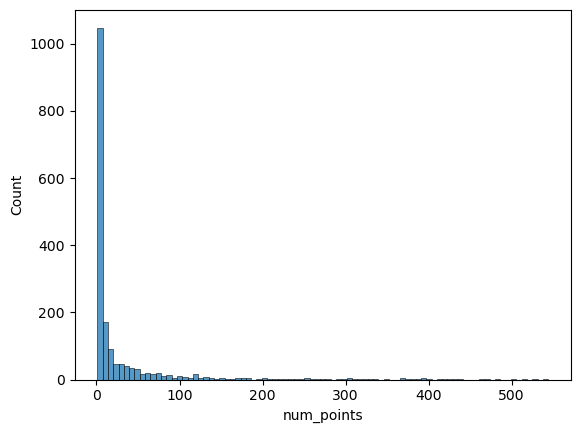

In [150]:
sns.histplot(data=df_final_bins, x='num_points')

<Axes: >

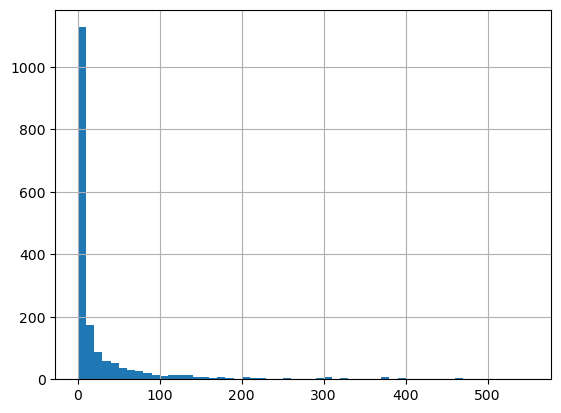

In [156]:
df_final_bins['num_points'].hist(bins=hist_bins, density=False)

<Axes: >

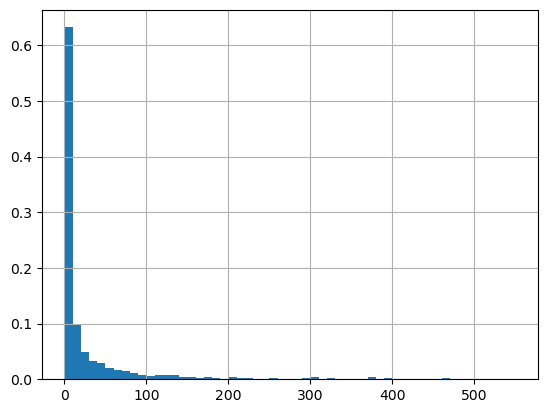

In [157]:
df_final_bins['num_points'].hist(bins=hist_bins, weights = list(np.ones_like(df_final_bins.index)/len(df_final_bins.index)))

In [171]:
adaptive_weights = list(np.ones_like(df_final_bins.index)/len(df_final_bins.index))
len(adaptive_weights)

1782

In [175]:
uniform_weights = list(np.ones_like(df_density_uniform.index)/len(df_density_uniform.index))
len(uniform_weights)

19324

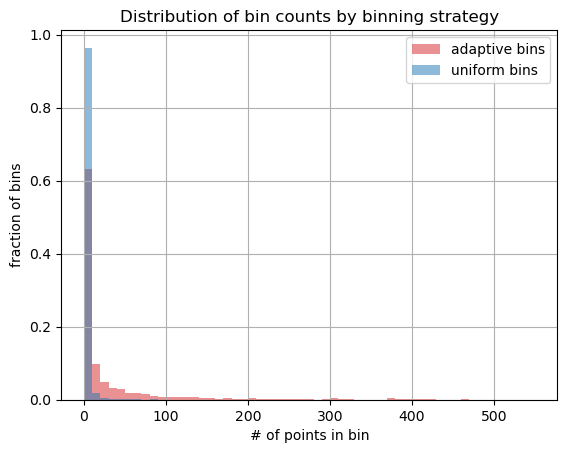

In [192]:
fix, ax = plt.subplots()

# df_density_uniform['counts'].plot(
#     kind = 'hist', ax = ax, color = 'tab:blue', label = 'uniform bins', bins = hist_bins, weights = uniform_weights
# )

# df_final_bins['num_points'].plot(
#     kind = 'hist', ax = ax, color = 'tab:red', label = 'adaptive bins', bins = hist_bins, weights = adaptive_weights
# )

df_final_bins['num_points'].hist(ax = ax, color = 'tab:red', label = 'adaptive bins', alpha = 0.5, bins=hist_bins, weights = adaptive_weights)
df_density_uniform['counts'].hist(ax = ax, color = 'tab:blue', label = 'uniform bins', alpha = 0.5, bins=hist_bins, weights = uniform_weights)

plt.title('Distribution of bin counts by binning strategy')
plt.xlabel('# of points in bin')
plt.ylabel('fraction of bins')

plt.legend()

In [194]:
df_final_bins

,bin_lower_limits,bin_upper_limits,iter,num_points
0,"[-34.21491241455078, -29.359601974487305, -27....","[-33.76582297682762, -28.92180789448321, -27.1...",6,52
1,"[-34.21491241455078, -29.359601974487305, -27....","[-33.76582297682762, -28.92180789448321, -27.1...",6,6
2,"[-34.21491241455078, -29.359601974487305, -27....","[-33.76582297682762, -28.92180789448321, -27.1...",6,1
3,"[-34.21491241455078, -29.359601974487305, -27....","[-33.76582297682762, -28.92180789448321, -27.1...",6,9
4,"[-34.21491241455078, -29.359601974487305, -27....","[-33.76582297682762, -28.92180789448321, -27.1...",6,14
...,...,...,...,...
1777,"[-6.371367275714874, -2.2163690142333508, 4.51...","[-5.473188400268555, -1.3407808542251587, 5.55...",5,1
1778,"[-6.371367275714874, -2.2163690142333508, 4.51...","[-5.473188400268555, -1.3407808542251587, 5.55...",5,2
1779,"[-6.371367275714874, -2.2163690142333508, 4.51...","[-5.473188400268555, -1.3407808542251587, 5.55...",5,44
1780,"[-6.371367275714874, -2.2163690142333508, 4.51...","[-5.473188400268555, -1.3407808542251587, 5.55...",5,37


In [196]:
df_final_bins.iloc[0,:]['bin_lower_limits'][0]

-34.21491241455078

In [197]:
# generate a point at center of each bin - ONLY ONES THAT HAVE POINTS IN THEM
# decode CFM
# num_bins_per_dim

# NOTE: need to fix this to use size of each bin! not uniform anymore 
# it actually may be easier since now I'm storing the coordinates
center_bin_coords = []
for row in df_final_bins.itertuples():
    # compute coord for each latent dimension
    this_bin_coords = []
    for dim in range(latent_dim):
        center_coord = (row.bin_lower_limits[dim] + row.bin_upper_limits[dim]) / 2
        this_bin_coords.append(center_coord)
    center_bin_coords.append(this_bin_coords)

In [217]:
# generate a point at center of each bin - only if > 1 point

center_bin_coords_dense = []
for row in df_final_bins.itertuples():
    # compute coord for each latent dimension
    if row.num_points > 1:
        this_bin_coords = []
        for dim in range(latent_dim):
            center_coord = (row.bin_lower_limits[dim] + row.bin_upper_limits[dim]) / 2
            this_bin_coords.append(center_coord)
        center_bin_coords_dense.append(this_bin_coords)

In [220]:
len(center_bin_coords)

1782

In [219]:
len(center_bin_coords_dense)

1309

In [202]:
df_latent

,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,z_10,label,decoded_cfm
0,-24.256855,-18.943563,-19.148005,-13.069660,-7.281853,-6.647669,-1.973320,1.312754,5.479063,10.920240,2,1.048495
1,-32.498856,-27.973068,-25.985146,-23.571732,-19.487030,-15.888780,-14.033054,-9.226448,-8.665678,-4.734122,3,1.236806
2,-17.562922,-16.157148,-7.969545,-5.897250,1.853780,4.455924,9.762284,14.726957,23.734491,29.096786,2,1.044764
3,-28.858011,-24.174309,-22.691444,-19.941648,-16.066748,-12.556651,-10.494271,-5.782712,-5.136093,-1.035175,3,-0.825561
4,-10.571421,-6.463661,0.640753,7.082870,11.920109,17.315226,24.198599,28.219280,36.607440,41.267610,0,0.690024
...,...,...,...,...,...,...,...,...,...,...,...,...
56645,-28.579952,-23.901604,-22.118683,-19.591473,-15.684873,-12.046993,-10.108648,-5.416104,-4.710186,-0.721344,3,0.267969
56646,-7.582398,-3.366018,3.963249,10.430345,15.107400,20.847500,27.655052,31.937830,40.201540,44.993100,0,-0.972245
56647,-17.119564,-13.705447,-7.196110,-4.540887,3.223161,5.727212,10.905486,15.751303,24.399230,29.637558,2,0.547159
56648,-29.270935,-24.531736,-22.611712,-20.303423,-16.054407,-12.572237,-10.648892,-5.845601,-5.259646,-1.332067,3,1.229240


## Try openTSNE: plot new points into existing embedding

In [204]:
tsne = oTSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=8,
    random_state=22,
    verbose=True,
)

In [205]:
embedding_latent_space = tsne.fit(latent_space)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=22, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 2.91 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.39 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=4720.83 for 250 iterations...
Iteration   50, KL divergence 5.2331, 50 iterations in 0.8460 sec
Iteration  100, KL divergence 4.6234, 50 iterations in 0.8892 sec
Iteration  150, KL divergence 4.3193, 50 iterations in 0.7632 sec
Iteration  200, KL divergence 4.1674, 50 iterations in 0.7942 sec
Iteration  250, KL divergence 4.0758, 50 iterations in 0.8270 sec
   --> Time elapsed: 4.12 seconds
===> Running optimization with exaggeration=1

In [206]:
embedding_latent_space

TSNEEmbedding([[-41.28083376,  39.6032496 ],
               [-75.4919926 , -73.31284881],
               [  9.08856473, -42.50148599],
               ...,
               [  8.40103003, -12.41512611],
               [-64.37894851,  71.68339732],
               [-25.73155704,  10.47155475]], shape=(56650, 2))

In [207]:
df_otsne = pd.DataFrame(embedding_latent_space, columns = ['t-SNE 1', 't-SNE 2'])
df_otsne['label'] = df_latent['label']
df_otsne['decoded_cfm'] = df_latent['decoded_cfm']

In [208]:
df_otsne

,t-SNE 1,t-SNE 2,label,decoded_cfm
0,-41.280834,39.603250,2,1.048495
1,-75.491993,-73.312849,3,1.236806
2,9.088565,-42.501486,2,1.044764
3,-49.935022,67.603311,3,-0.825561
4,67.344851,-85.507155,0,0.690024
...,...,...,...,...
56645,-44.487827,90.822098,3,0.267969
56646,76.132638,81.997176,0,-0.972245
56647,8.401030,-12.415126,2,0.547159
56648,-64.378949,71.683397,3,1.229240


In [209]:
embedding_nonempty = embedding_latent_space.transform(np.array(center_bin_coords))

===> Finding 15 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 0.06 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 20169.7412, 50 iterations in 1.0852 sec
Iteration  100, KL divergence 20095.2445, 50 iterations in 1.1179 sec
Iteration  150, KL divergence 20085.6121, 50 iterations in 1.0540 sec
Iteration  200, KL divergence 20085.6166, 50 iterations in 1.0602 sec
Iteration  250, KL divergence 20085.6151, 50 iterations in 1.1075 sec
   --> Time elapsed: 5.43 seconds


In [221]:
embedding_dense = embedding_latent_space.transform(np.array(center_bin_coords_dense))

===> Finding 15 nearest neighbors in existing embedding using Annoy approximate search...
   --> Time elapsed: 0.05 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 14451.3329, 50 iterations in 0.9987 sec
Iteration  100, KL divergence 14393.8184, 50 iterations in 1.0443 sec
Iteration  150, KL divergence 14384.3434, 50 iterations in 1.0881 sec
Iteration  200, KL divergence 14384.3477, 50 iterations in 1.0358 sec
Iteration  250, KL divergence 14384.3463, 50 iterations in 1.0224 sec
   --> Time elapsed: 5.19 seconds


In [222]:
df_otsne_nonempty = pd.DataFrame(embedding_nonempty, columns = ['t-SNE 1', 't-SNE 2'])
df_otsne_dense = pd.DataFrame(embedding_dense, columns = ['t-SNE 1', 't-SNE 2'])

In [211]:
df_otsne_nonempty

,t-SNE 1,t-SNE 2
0,-105.033180,-18.833886
1,-99.897070,-21.001602
2,-95.309916,-25.707809
3,-101.206179,-20.754137
4,-94.914887,-26.203866
...,...,...
1777,92.210540,42.437001
1778,86.800555,42.741355
1779,87.907495,41.585194
1780,89.735291,39.952146


In [223]:
df_otsne_dense

,t-SNE 1,t-SNE 2
0,-105.033180,-18.833886
1,-99.897070,-21.001602
2,-101.206179,-20.754137
3,-94.914887,-26.203866
4,-94.228348,-27.685183
...,...,...
1304,89.703266,40.003676
1305,86.800555,42.741355
1306,87.907495,41.585194
1307,89.735291,39.952146


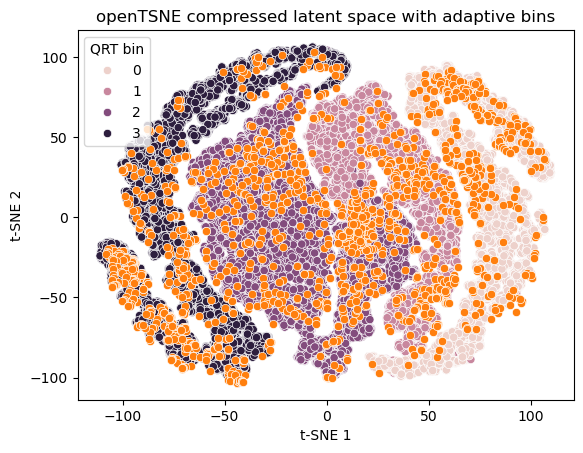

In [216]:
plt.figure()
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='label', data=df_otsne)
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_otsne_nonempty)
# ax1 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56651:56738,:], color='green') # higher-density bins (86)
# ax2 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56738:,:], color='orange') # lower-density bins (68)
plt.title('openTSNE compressed latent space with adaptive bins')
plt.legend(title = 'QRT bin')

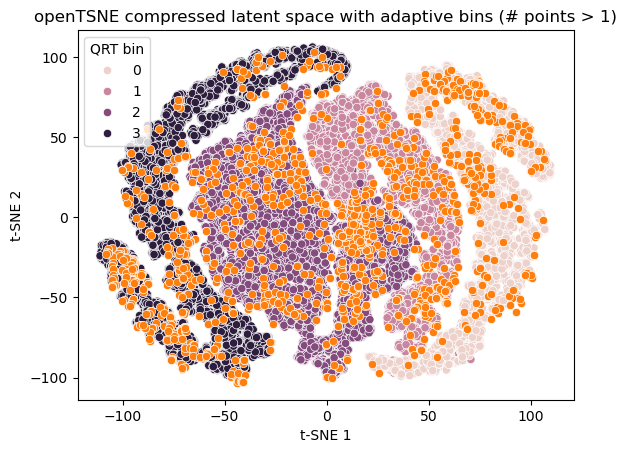

In [225]:
plt.figure()
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='label', data=df_otsne)
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_otsne_dense)
# ax1 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56651:56738,:], color='green') # higher-density bins (86)
# ax2 = sns.scatterplot(x='t-SNE 1', y='t-SNE 2', data=df_tsne_nonempty.iloc[56738:,:], color='orange') # lower-density bins (68)
plt.title('openTSNE compressed latent space with adaptive bins (# points > 1)')
plt.legend(title = 'QRT bin')

In [ ]:
# FIND LABELS FOR THE NEW POINTS - HOW????
# EVENTUALLY WANT TO DO BELOW:
# nonempty_bin_generated_cfm = decode_cfm_along_trajectory(model, center_bin_coords, center_bin_labels, device=device)

/tmp/ipykernel_52262/4170169750.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap3 = cm.get_cmap('viridis')


<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

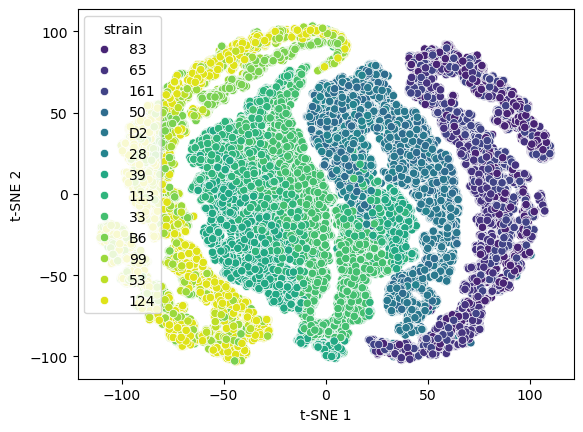

In [ ]:
# WHAT IS THIS MESS????
# FIXED! Was pulling strain info from df_gene, which has different ordering of points

strain_order = ['83', '65', '161', '50', 'D2', '28', '39', '113', '33', 'B6', '99', '53',
 '124']

cmap3 = cm.get_cmap('viridis')
custom_palette = [cmap3(0.1), cmap3(0.15), cmap3(0.2), cmap3(0.35), cmap3(0.4), cmap3(0.45), cmap3(0.6), cmap3(0.65), cmap3(0.7), cmap3(0.8), cmap3(0.85), cmap3(0.9), cmap3(0.95)]
temp = df_otsne.copy()
temp["strain"] = temp["strain"].astype(str)

sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue="strain",hue_order = strain_order, palette=custom_palette, data=df_otsne)